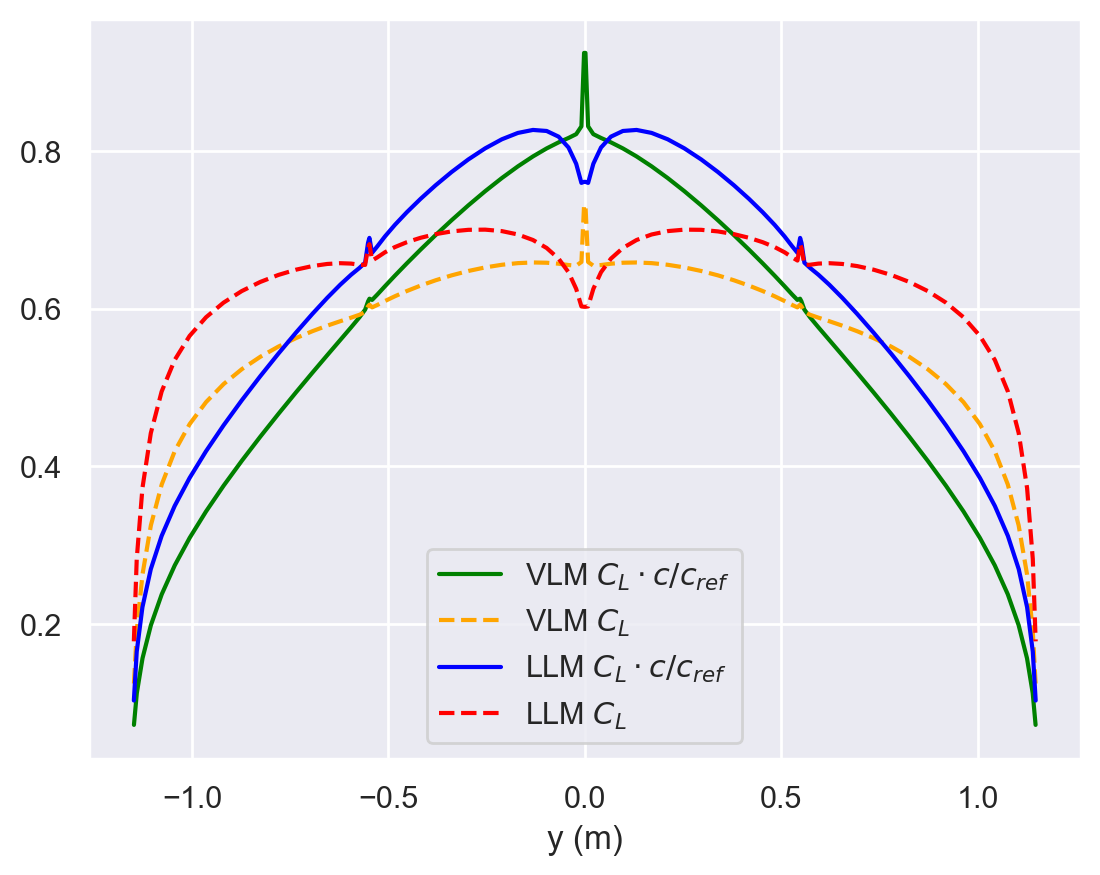

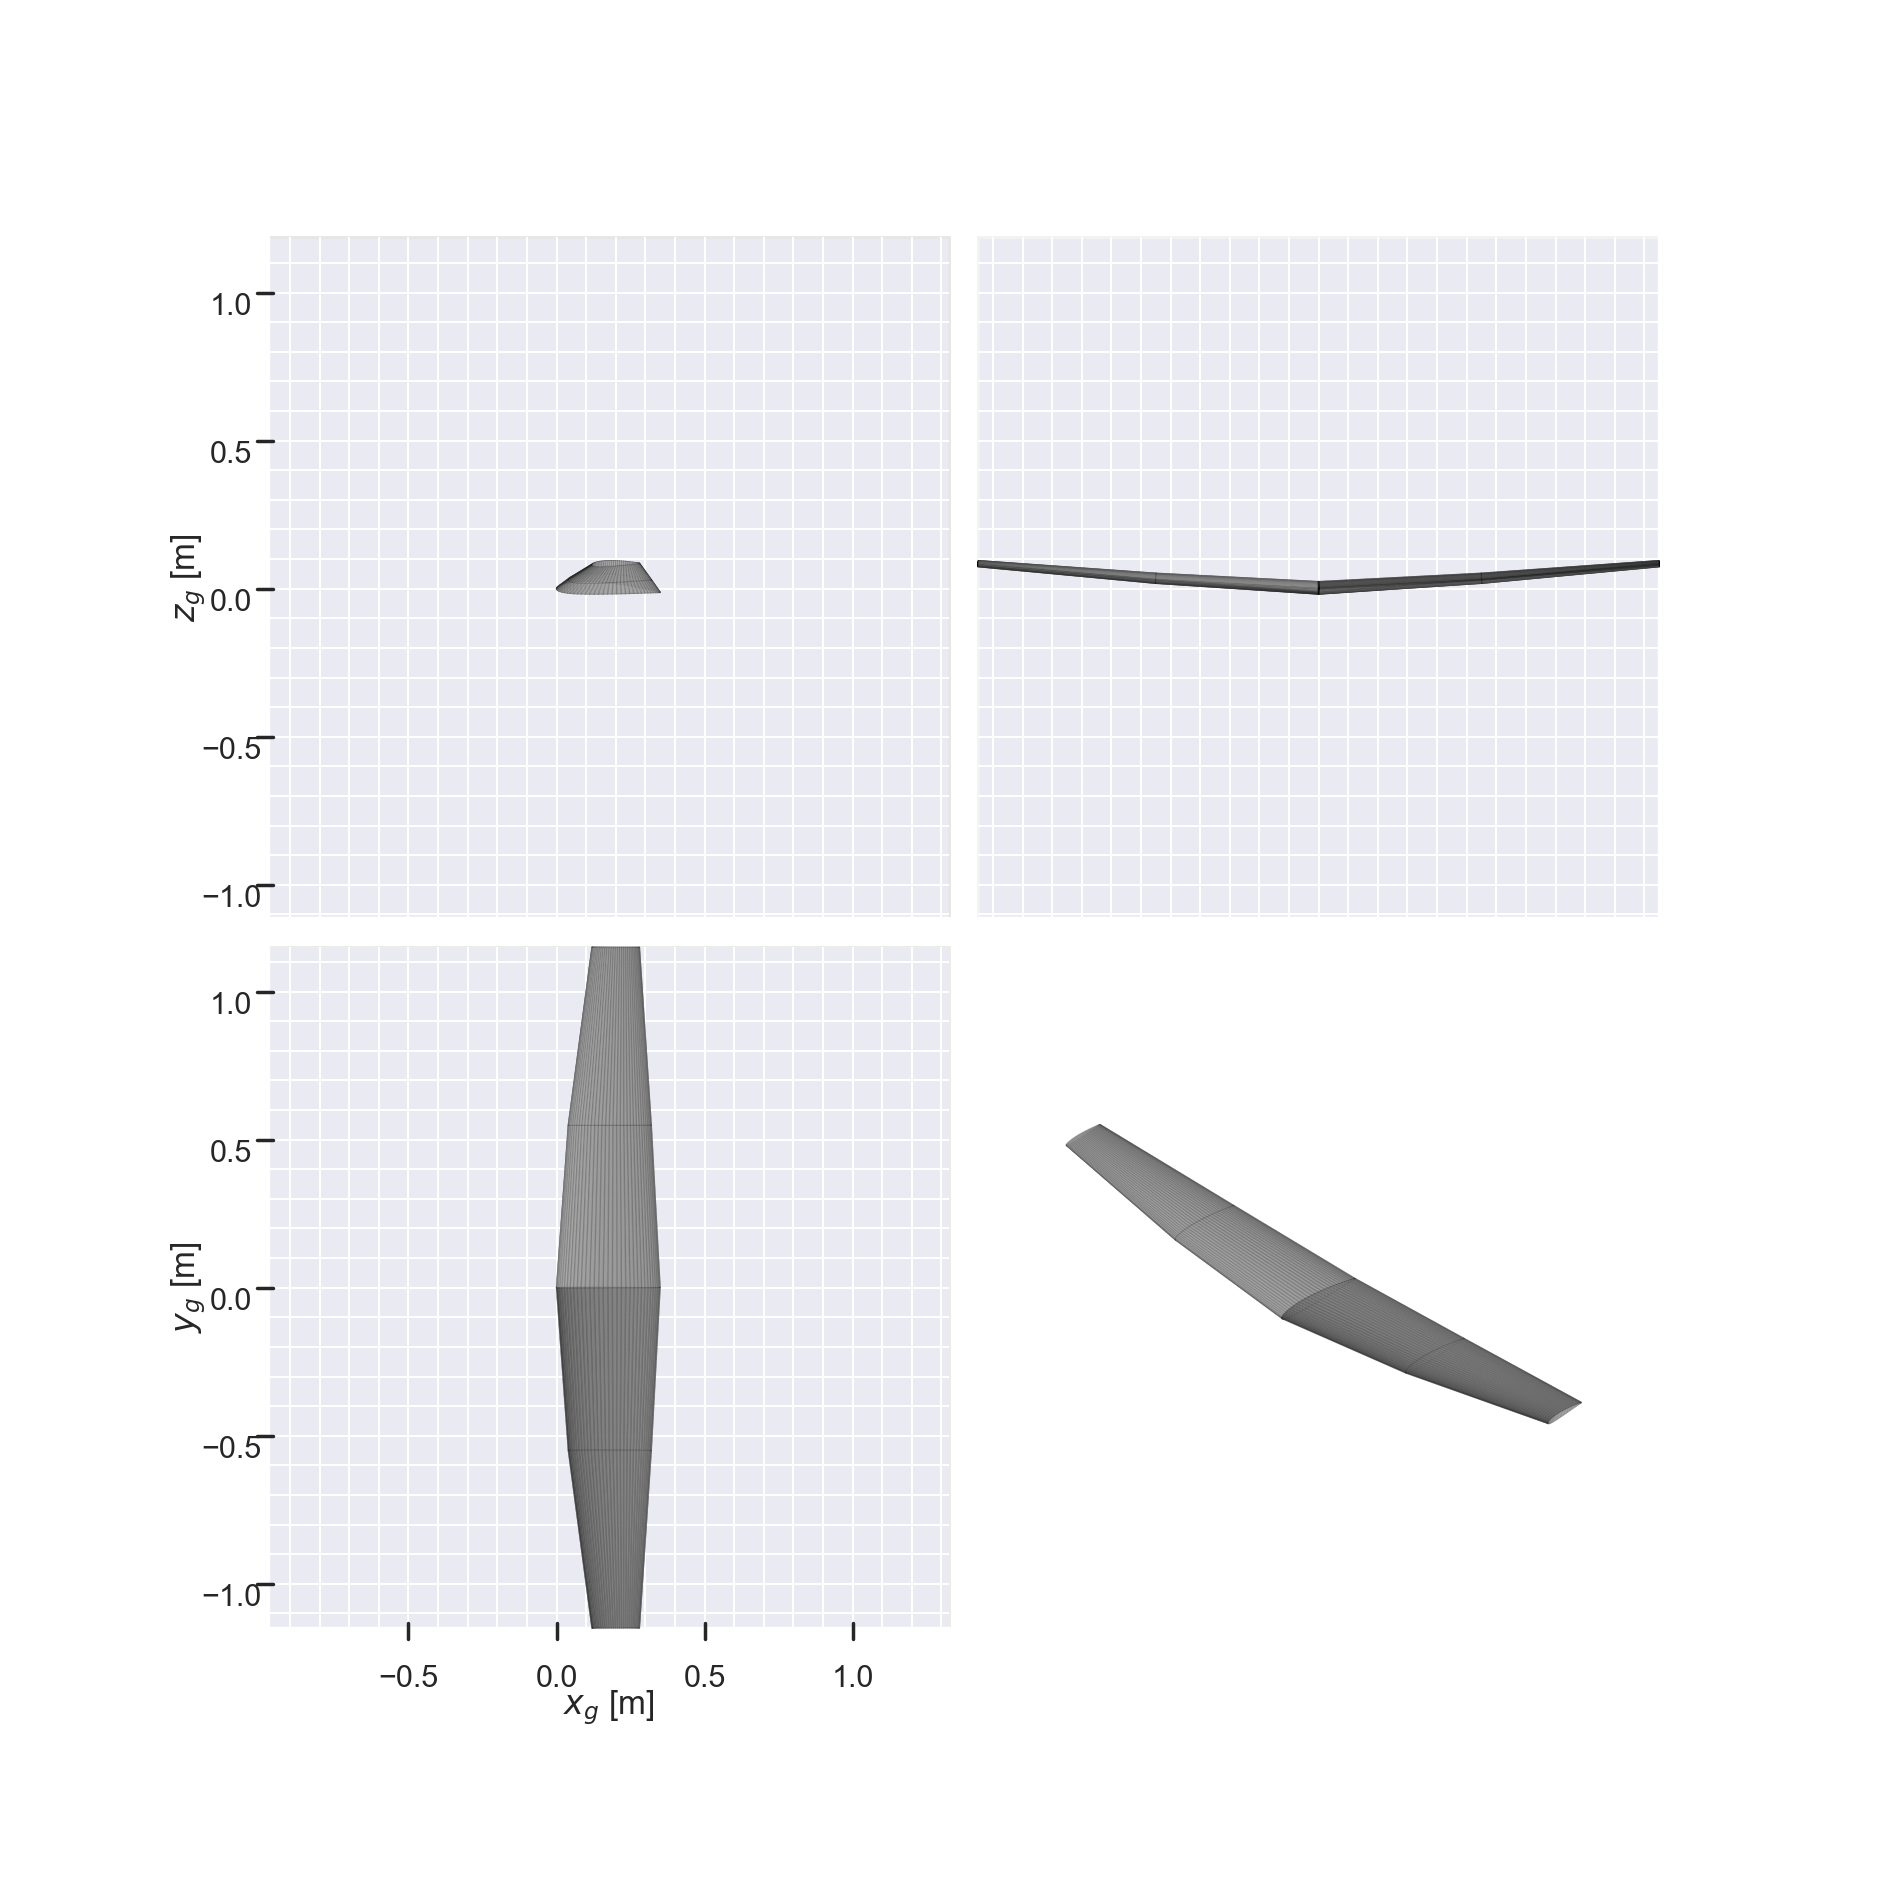

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [5]:
import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt

velocity = 20
alpha = 5
spanwise_resolution = 20

wing_airplane = asb.Airplane(
    name="Generic Wing",
    xyz_ref=[0.25, 0, 0],
    wings=[
        asb.Wing(
            name="Wing",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[0, 0, 0],
                    chord=0.35,
                    twist=2,
                    airfoil=asb.Airfoil("naca2412"),
                ),
                asb.WingXSec(
                    xyz_le=[0.04, 0.55, 0.03],
                    chord=0.28,
                    twist=0,
                    airfoil=asb.Airfoil("naca2412"),
                ),
                asb.WingXSec(
                    xyz_le=[0.12, 1.15, 0.08],
                    chord=0.16,
                    twist=-2,
                    airfoil=asb.Airfoil("naca2412"),
                ),
            ],
        )
    ],
)

op_point = asb.OperatingPoint(velocity=velocity, alpha=alpha)

vlm = asb.VortexLatticeMethod(
    airplane=wing_airplane,
    op_point=op_point,
    spanwise_resolution=spanwise_resolution,
    chordwise_resolution=4,
    align_trailing_vortices_with_wind=False,
    vortex_core_radius=1e-6,
)
vlm_results = vlm.run()

llm = asb.LiftingLine(
    airplane=wing_airplane,
    op_point=op_point,
    spanwise_resolution=spanwise_resolution,
    align_trailing_vortices_with_wind=False,
)
llm_results = llm.run()

wing_y_vlm = vlm["y"][0]
wing_clc_over_cref_vlm = vlm["clc_over_cref"][0]
wing_cl_vlm = vlm["cl"][0]

wing_y_llm = llm["y"][0]
wing_clc_over_cref_llm = llm["clc_over_cref"][0]
wing_cl_llm = llm["cl"][0]

plt.plot(wing_y_vlm, wing_clc_over_cref_vlm, color="green", label=r"VLM $C_L \cdot c/c_{ref}$")
plt.plot(wing_y_vlm, wing_cl_vlm, color="orange", linestyle="--", label=r"VLM $C_L$")
plt.plot(wing_y_llm, wing_clc_over_cref_llm, color="blue", label=r"LLM $C_L \cdot c/c_{ref}$")
plt.plot(wing_y_llm, wing_cl_llm, color="red", linestyle="--", label=r"LLM $C_L$")
plt.xlabel("y (m)")
plt.legend()
plt.show()

wing_airplane.draw_three_view()

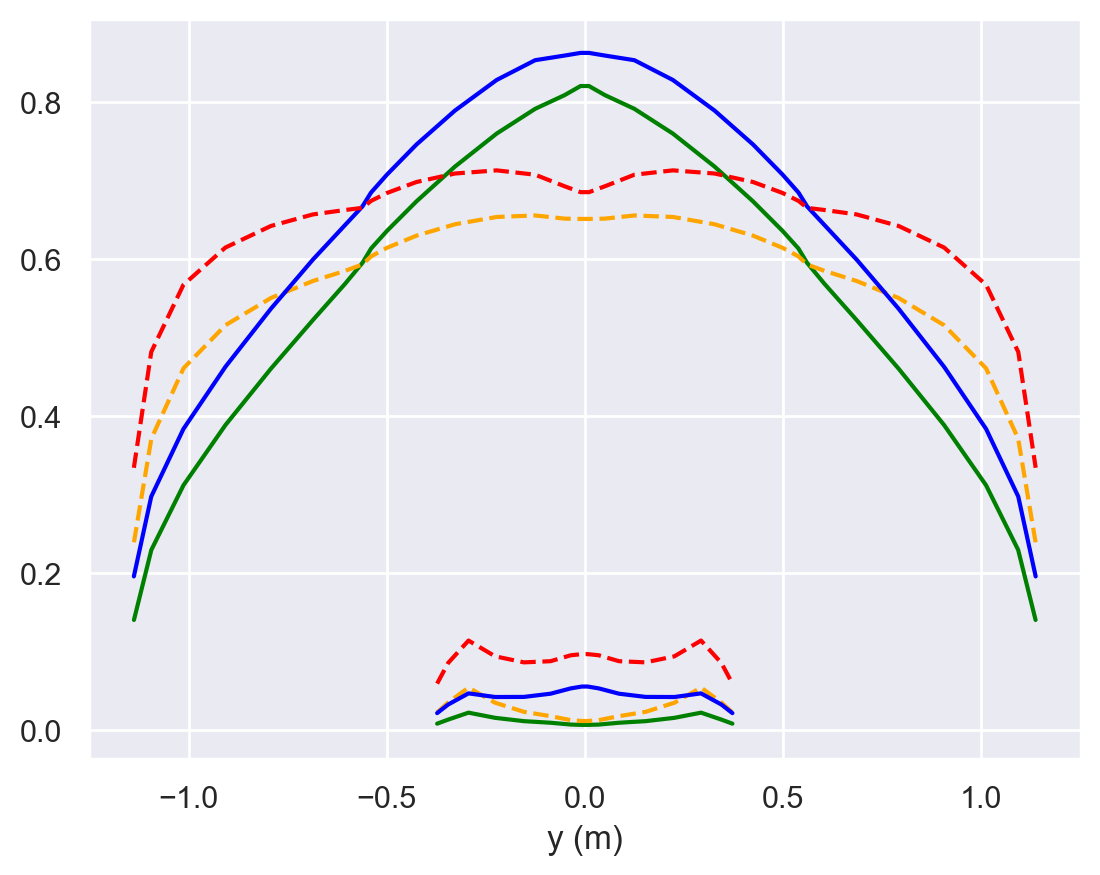

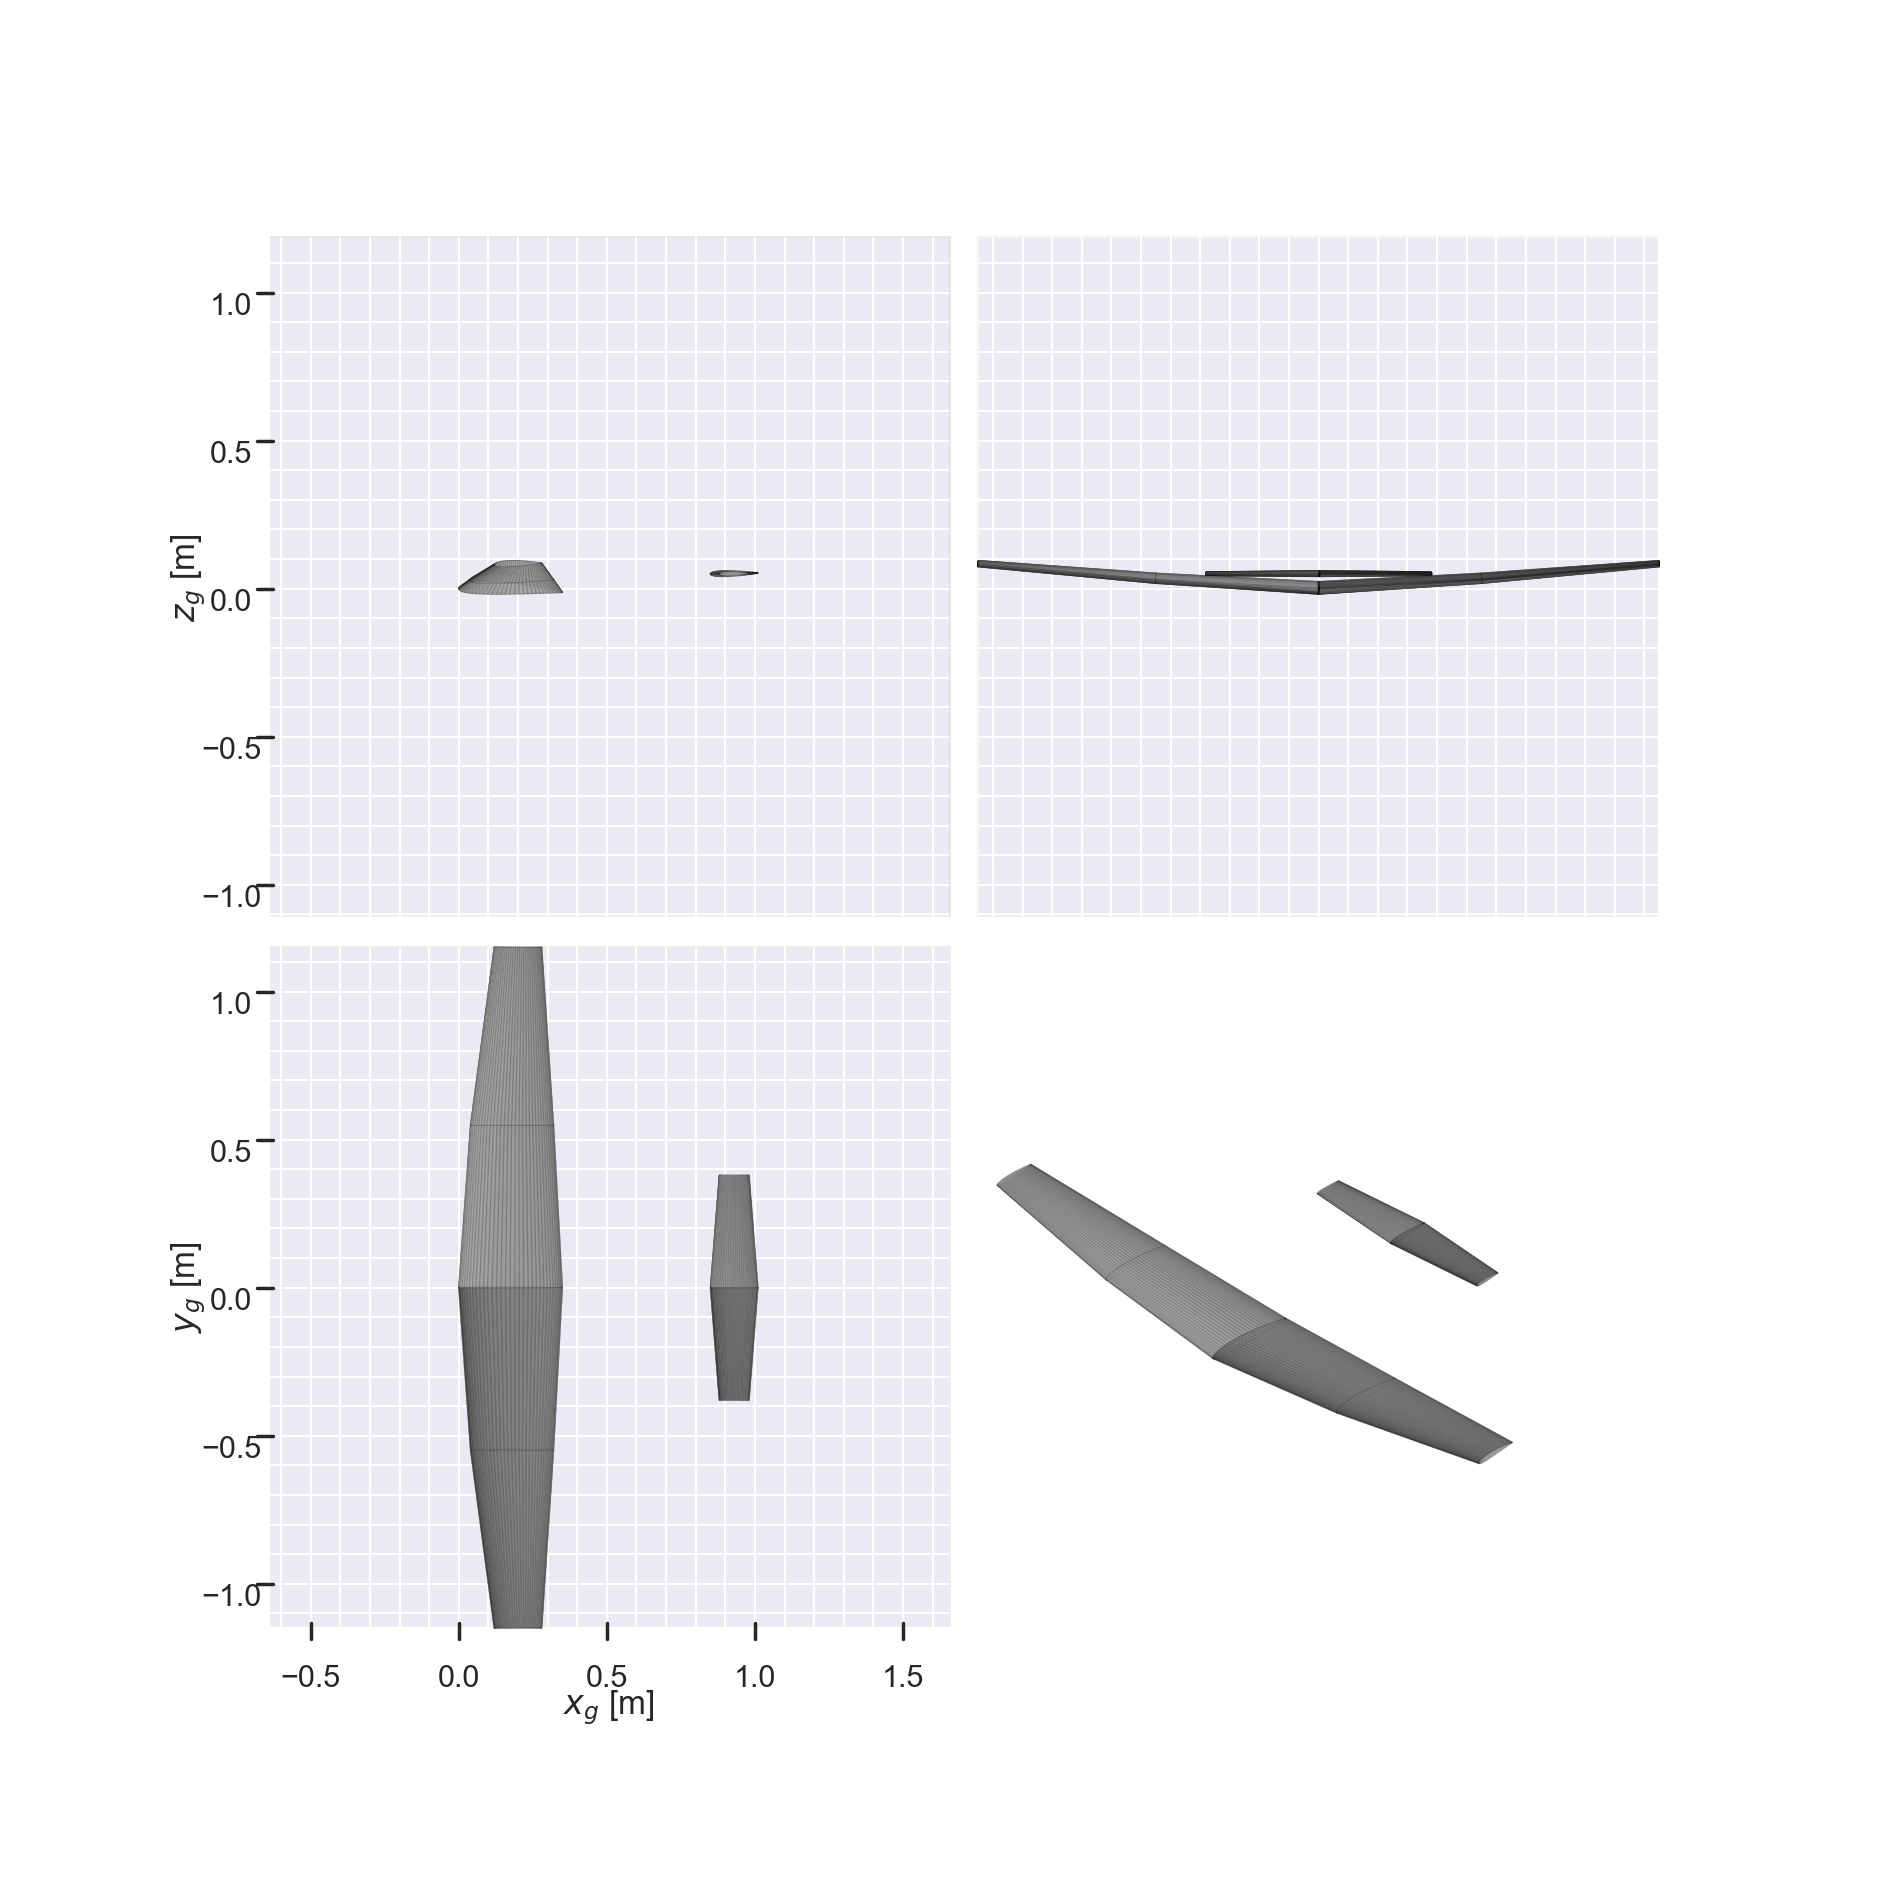

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [16]:
wing_tail_airplane = asb.Airplane(
    name="Generic Wing and Tail",
    xyz_ref=[0.25, 0, 0],
    wings=[
        asb.Wing(
            name="Main Wing",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[0, 0, 0],
                    chord=0.35,
                    twist=2,
                    airfoil=asb.Airfoil("naca2412"),
                ),
                asb.WingXSec(
                    xyz_le=[0.04, 0.55, 0.03],
                    chord=0.28,
                    twist=0,
                    airfoil=asb.Airfoil("naca2412"),
                ),
                asb.WingXSec(
                    xyz_le=[0.12, 1.15, 0.08],
                    chord=0.16,
                    twist=-2,
                    airfoil=asb.Airfoil("naca2412"),
                ),
            ],
        ),
        asb.Wing(
            name="Horizontal Tail",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[0.85, 0, 0.05],
                    chord=0.16,
                    twist=-1,
                    airfoil=asb.Airfoil("naca0012"),
                ),
                asb.WingXSec(
                    xyz_le=[0.88, 0.38, 0.05],
                    chord=0.10,
                    twist=-1,
                    airfoil=asb.Airfoil("naca0012"),
                ),
            ],
        ),
    ],
)

op_point = asb.OperatingPoint(velocity=velocity, alpha=alpha)

vlm = asb.VortexLatticeMethod(
    airplane=wing_tail_airplane,
    op_point=op_point,
    spanwise_resolution=spanwise_resolution,
    chordwise_resolution=4,
    align_trailing_vortices_with_wind=False,
)
vlm_results = vlm.run()

llm = asb.LiftingLine(
    airplane=wing_tail_airplane,
    op_point=op_point,
    spanwise_resolution=spanwise_resolution,
    align_trailing_vortices_with_wind=False,
)
llm_results = llm.run()

wing_y_vlm = vlm["y"][0]
wing_clc_over_cref_vlm = vlm["clc_over_cref"][0]
wing_cl_vlm = vlm["cl"][0]

tail_y_vlm = vlm["y"][1]
tail_clc_over_cref_vlm = vlm["clc_over_cref"][1]
tail_cl_vlm = vlm["cl"][1]

wing_y_llm = llm["y"][0]
wing_clc_over_cref_llm = llm["clc_over_cref"][0]
wing_cl_llm = llm["cl"][0]

tail_y_llm = llm["y"][1]
tail_clc_over_cref_llm = llm["clc_over_cref"][1]
tail_cl_llm = llm["cl"][1]

plt.plot(wing_y_vlm, wing_clc_over_cref_vlm, color="green", label=r"VLM $C_L \cdot c/c_{ref}$")
plt.plot(wing_y_vlm, wing_cl_vlm, color="orange", linestyle="--", label=r"VLM $C_L$")

plt.plot(tail_y_vlm, tail_clc_over_cref_vlm, color="green", label=r"VLM $C_L \cdot c/c_{ref}$")
plt.plot(tail_y_vlm, tail_cl_vlm, color="orange", linestyle="--", label=r"VLM $C_L$")

plt.plot(wing_y_llm, wing_clc_over_cref_llm, color="blue", label=r"LLM $C_L \cdot c/c_{ref}$")
plt.plot(wing_y_llm, wing_cl_llm, color="red", linestyle="--", label=r"LLM $C_L$")

plt.plot(tail_y_llm, tail_clc_over_cref_llm, color="blue", label=r"VLM $C_L \cdot c/c_{ref}$")
plt.plot(tail_y_llm, tail_cl_llm, color="red", linestyle="--", label=r"VLM $C_L$")

plt.xlabel("y (m)")
plt.show()

wing_tail_airplane.draw_three_view()